- Batch 1: Network type (random vs clustered) × Influencer ratio
- Batch 2: Network Density × Tie Strength
- Batch 3: Threshold mean × Friend tie ratio
- Batch 4: Network Type × Threshold Mean 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from model import ScarcityModel

In [2]:
# helper function 1

def run_model(**kwargs):
    """
    Run one ScarcityModel with the given parameters.
    Stops when model.running = False or after 200 steps.
    """
    # create model with whatever parameters are passed in
    model = ScarcityModel(**kwargs)

    # run step by step until cascade resolves or 200 steps reached
    for _ in range(200):
        if not model.running:
            break
        model.step()

    # get the last row of collected data (final state)
    data = model.datacollector.get_model_vars_dataframe()
    return {
        "Successful": int(data["Successful"].iloc[-1]),
        "Failed": int(data["Failed"].iloc[-1]),
    }

In [3]:
# helper function 2

def run_ttest(label, group_a, group_b, name_a, name_b):
    """
    Compare two groups using an independent-samples t-test.
    """
    t, p = stats.ttest_ind(group_a, group_b)
    # assign significance stars based on p-value
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    print(f"[{label}] {name_a} (M={group_a.mean():.1f}) vs "
          f"{name_b} (M={group_b.mean():.1f}) -> t={t:.2f}, p={p:.4f} {sig}")
    return t, p


# number of times to repeat each parameter combination
RUNS = 10

#### Batch 1

In [4]:
# data collection

rows = []
for network_type in ["random", "clustered"]:
    for influencer_ratio in [0.0, 0.05, 0.1, 0.2]:
        for _ in range(RUNS):
            result = run_model(
                network_type = network_type,
                influencer_ratio = influencer_ratio,
                initial_supply = 20,
                restock_rate = 0.2,
                threshold_mean = 0.6,
                friend_ratio = 0.3,
            )
            # store parameter values alongside results
            rows.append({
                "network_type": network_type,
                "influencer_ratio": influencer_ratio,
                **result
            })

df1 = pd.DataFrame(rows)
df1.head(8)

,network_type,influencer_ratio,Successful,Failed
0,random,0.0,24,10
1,random,0.0,24,2
2,random,0.0,21,0
3,random,0.0,24,4
4,random,0.0,9,0
5,random,0.0,16,0
6,random,0.0,5,0
7,random,0.0,24,5


In [5]:
# statistical test

# t-test: compare random vs clustered across all influencer levels
print("Overall t-test: random vs clustered")
t1, p1 = run_ttest(
    "overall",
    df1[df1["network_type"] == "random"]["Successful"],
    df1[df1["network_type"] == "clustered"]["Successful"],
    "random", "clustered"
)

# t-test at each influencer ratio level separately
print("\nT-tests at each influencer ratio:")
for ir in [0.0, 0.05, 0.1, 0.2]:
    sub = df1[df1["influencer_ratio"] == ir]
    run_ttest(
        f"influencer={ir}",
        sub[sub["network_type"] == "random"]["Successful"],
        sub[sub["network_type"] == "clustered"]["Successful"],
        "random", "clustered"
    )

Overall t-test: random vs clustered
[overall] random (M=21.5) vs clustered (M=24.2) -> t=-2.93, p=0.0044 **

T-tests at each influencer ratio:
[influencer=0.0] random (M=17.0) vs clustered (M=25.8) -> t=-3.41, p=0.0031 **
[influencer=0.05] random (M=22.9) vs clustered (M=23.6) -> t=-0.57, p=0.5779 n.s.
[influencer=0.1] random (M=23.2) vs clustered (M=24.8) -> t=-1.12, p=0.2794 n.s.
[influencer=0.2] random (M=23.0) vs clustered (M=22.8) -> t=0.19, p=0.8498 n.s.


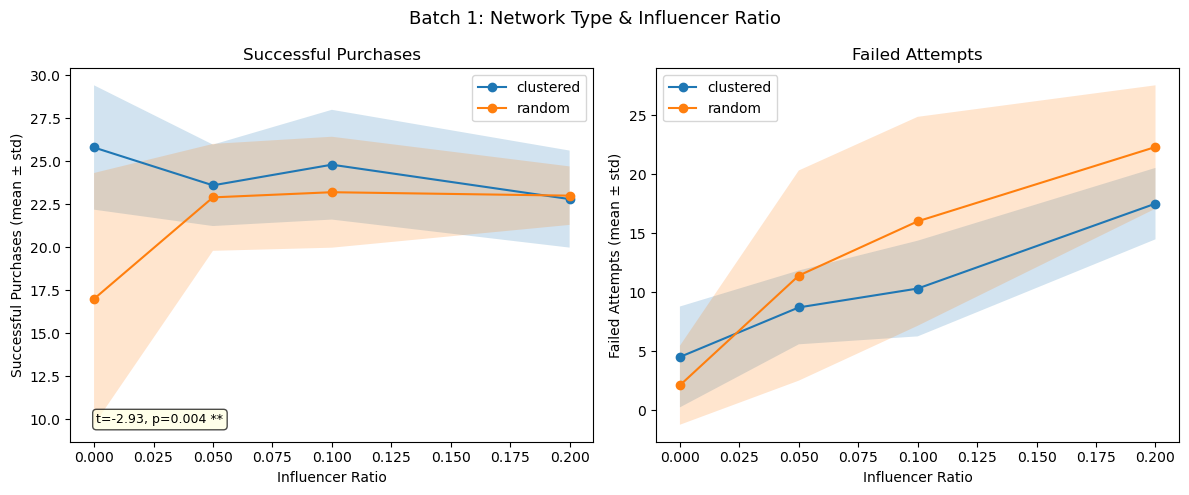

In [6]:
# plot

fig1, axes1 = plt.subplots(1, 2, figsize=(12, 5))
fig1.suptitle("Batch 1: Network Type & Influencer Ratio", fontsize=13)

# Successful purchases
# Group by network_type, then compute mean and std at each influencer_ratio level
for net_type, group in df1.groupby("network_type"):
    s = group.groupby("influencer_ratio")["Successful"].agg(["mean", "std"]).reset_index()
    axes1[0].plot(s["influencer_ratio"], s["mean"], marker="o", label=net_type)
    # shaded band = mean ± 1 std
    axes1[0].fill_between(s["influencer_ratio"],
                          s["mean"] - s["std"],
                          s["mean"] + s["std"], alpha=0.2)

# annotate overall t-test result on the plot
sig1 = "***" if p1 < 0.001 else "**" if p1 < 0.01 else "*" if p1 < 0.05 else "n.s."
axes1[0].text(0.05, 0.05, f"t={t1:.2f}, p={p1:.3f} {sig1}",
              transform=axes1[0].transAxes, fontsize=9,
              bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.7))
axes1[0].set_xlabel("Influencer Ratio")
axes1[0].set_ylabel("Successful Purchases (mean ± std)")
axes1[0].set_title("Successful Purchases")
axes1[0].legend()

# Failed attempts
for net_type, group in df1.groupby("network_type"):
    s = group.groupby("influencer_ratio")["Failed"].agg(["mean", "std"]).reset_index()
    axes1[1].plot(s["influencer_ratio"], s["mean"], marker="o", label=net_type)
    axes1[1].fill_between(s["influencer_ratio"],
                          s["mean"] - s["std"],
                          s["mean"] + s["std"], alpha=0.2)
axes1[1].set_xlabel("Influencer Ratio")
axes1[1].set_ylabel("Failed Attempts (mean ± std)")
axes1[1].set_title("Failed Attempts")
axes1[1].legend()

fig1.tight_layout()
plt.show()

#### Batch 2

In [4]:
# data collection

rows = []
for avg_node_degree in [2, 4, 6, 8]:
    for friend_ratio in [0.1, 0.3, 0.5]:
        for _ in range(RUNS):
            result = run_model(
                avg_node_degree = avg_node_degree,
                friend_ratio = friend_ratio,
                # parameters held constant across Batch 2
                network_type = "random",
                influencer_ratio = 0.05,
                threshold_mean = 0.6,
                initial_supply = 40,
                restock_rate = 0.2,
            )
            rows.append({"avg_node_degree": avg_node_degree,
                         "friend_ratio": friend_ratio,
                         **result})
 
df2 = pd.DataFrame(rows)
df2.head(8)

,avg_node_degree,friend_ratio,Successful,Failed
0,2,0.1,25,0
1,2,0.1,22,0
2,2,0.1,43,0
3,2,0.1,49,8
4,2,0.1,21,0
5,2,0.1,48,2
6,2,0.1,36,0
7,2,0.1,47,0


In [5]:
# statistical test

corr_d, p_d = stats.pearsonr(df2["avg_node_degree"], df2["Successful"])
corr_f, p_f = stats.pearsonr(df2["friend_ratio"], df2["Successful"])
print(f"\nr(avg_node_degree, Successful) = {corr_d:.3f}, p={p_d:.4f}")
print(f"r(friend_ratio, Successful) = {corr_f:.3f}, p={p_f:.4f}")

# compare low friend ratio (0.1) vs high friend ratio (0.5)
print("\nT-tests at each density level (friend=0.1 vs friend=0.5):")
for deg in [2, 4, 6, 8]:
    sub = df2[df2["avg_node_degree"] == deg]
    run_ttest(f"degree={deg}",
              sub[sub["friend_ratio"] == 0.1]["Successful"],
              sub[sub["friend_ratio"] == 0.5]["Successful"],
              "friend=0.1", "friend=0.5")


r(avg_node_degree, Successful) = -0.002, p=0.9857
r(friend_ratio, Successful) = -0.058, p=0.5284

T-tests at each density level (friend=0.1 vs friend=0.5):
[degree=2] friend=0.1 (M=35.4) vs friend=0.5 (M=35.5) -> t=-0.02, p=0.9826 n.s.
[degree=4] friend=0.1 (M=39.6) vs friend=0.5 (M=37.2) -> t=0.51, p=0.6195 n.s.
[degree=6] friend=0.1 (M=38.4) vs friend=0.5 (M=33.9) -> t=0.84, p=0.4130 n.s.
[degree=8] friend=0.1 (M=36.9) vs friend=0.5 (M=37.3) -> t=-0.07, p=0.9454 n.s.


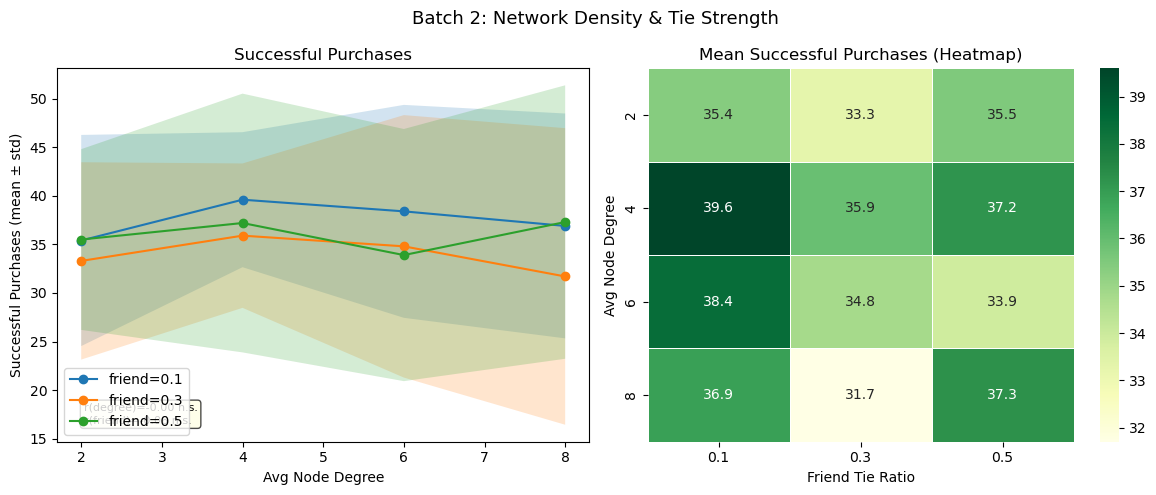

In [ ]:
# plot

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle("Batch 2: Network Density & Tie Strength", fontsize=13)
 
# line plot — one line per friend ratio level
for friend_r, group in df2.groupby("friend_ratio"):
    s = group.groupby("avg_node_degree")["Successful"].agg(["mean", "std"]).reset_index()
    axes2[0].plot(s["avg_node_degree"], s["mean"], marker="o", label=f"friend={friend_r}")
    axes2[0].fill_between(s["avg_node_degree"],
                          s["mean"] - s["std"],
                          s["mean"] + s["std"], alpha=0.2)
 
sig_d = "***" if p_d < 0.001 else "**" if p_d < 0.01 else "*" if p_d < 0.05 else "n.s."
sig_f = "***" if p_f < 0.001 else "**" if p_f < 0.01 else "*" if p_f < 0.05 else "n.s."
axes2[0].text(0.05, 0.05,
              f"r(degree)={corr_d:.2f} {sig_d}\nr(friend)={corr_f:.2f} {sig_f}",
              transform=axes2[0].transAxes, fontsize=8,
              bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.7))
axes2[0].set_xlabel("Avg Node Degree")
axes2[0].set_ylabel("Successful Purchases (mean ± std)")
axes2[0].set_title("Successful Purchases")
axes2[0].legend()
 
# heatmap — density × friend ratio
pivot2 = df2.groupby(["avg_node_degree", "friend_ratio"])["Successful"].mean().unstack()
sns.heatmap(pivot2, ax=axes2[1], annot=True, fmt=".1f", cmap="YlGn", linewidths=0.5)
axes2[1].set_title("Mean Successful Purchases (Heatmap)")
axes2[1].set_xlabel("Friend Tie Ratio")
axes2[1].set_ylabel("Avg Node Degree")
 
fig2.tight_layout()
plt.show()

#### Batch 3

In [10]:
# data collection

rows = []
for threshold_mean in [0.4, 0.5, 0.6, 0.7, 0.8]:
    for friend_ratio in [0.1, 0.3, 0.5]:
        for _ in range(RUNS):
            result = run_model(
                threshold_mean = threshold_mean,
                friend_ratio = friend_ratio,
                # parameters held constant across Batch 3
                network_type = "random",
                influencer_ratio = 0.05,
                initial_supply = 20,
                restock_rate = 0.2,
            )
            rows.append({
                "threshold_mean": threshold_mean,
                "friend_ratio": friend_ratio,
                **result
            })

df3 = pd.DataFrame(rows)
df3.head(8)

,threshold_mean,friend_ratio,Successful,Failed
0,0.4,0.1,20,24
1,0.4,0.1,20,7
2,0.4,0.1,20,22
3,0.4,0.1,21,24
4,0.4,0.1,20,29
5,0.4,0.1,20,21
6,0.4,0.1,20,9
7,0.4,0.1,20,20


In [11]:
# statistical test

corr_t, p_t = stats.pearsonr(df3["threshold_mean"], df3["Successful"])
corr_f, p_f = stats.pearsonr(df3["friend_ratio"], df3["Successful"])
print(f"r(threshold_mean, Successful) = {corr_t:.3f}, p={p_t:.4f}")
print(f"r(friend_ratio, Successful) = {corr_f:.3f}, p={p_f:.4f}")

# t-tests: does friend ratio matter at each threshold level?
print("\nT-tests at each threshold level (friend=0.1 vs friend=0.5):")
for thresh in [0.4, 0.5, 0.6, 0.7, 0.8]:
    sub = df3[df3["threshold_mean"] == thresh]
    run_ttest(
        f"threshold={thresh}",
        sub[sub["friend_ratio"] == 0.1]["Successful"],
        sub[sub["friend_ratio"] == 0.5]["Successful"],
        "friend=0.1", "friend=0.5"
    )

r(threshold_mean, Successful) = -0.253, p=0.0018
r(friend_ratio, Successful) = -0.100, p=0.2228

T-tests at each threshold level (friend=0.1 vs friend=0.5):
[threshold=0.4] friend=0.1 (M=20.1) vs friend=0.5 (M=20.0) -> t=1.00, p=0.3306 n.s.
[threshold=0.5] friend=0.1 (M=20.9) vs friend=0.5 (M=20.8) -> t=0.19, p=0.8502 n.s.
[threshold=0.6] friend=0.1 (M=23.7) vs friend=0.5 (M=23.3) -> t=0.84, p=0.4096 n.s.
[threshold=0.7] friend=0.1 (M=21.7) vs friend=0.5 (M=19.6) -> t=0.63, p=0.5359 n.s.
[threshold=0.8] friend=0.1 (M=17.9) vs friend=0.5 (M=13.1) -> t=1.05, p=0.3065 n.s.


/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


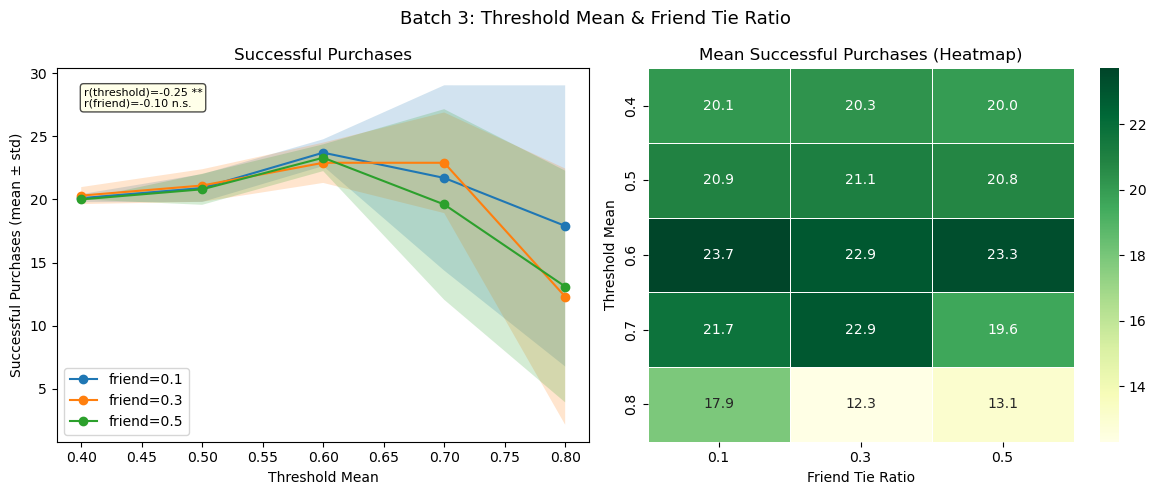

In [12]:
# plot

fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5))
fig3.suptitle("Batch 3: Threshold Mean & Friend Tie Ratio", fontsize=13)

# one line per friend ratio level
for friend_r, group in df3.groupby("friend_ratio"):
    s = group.groupby("threshold_mean")["Successful"].agg(["mean", "std"]).reset_index()
    axes3[0].plot(s["threshold_mean"], s["mean"], marker="o", label=f"friend={friend_r}")
    axes3[0].fill_between(s["threshold_mean"],
                          s["mean"] - s["std"],
                          s["mean"] + s["std"], alpha=0.2)

# annotate correlation results
sig_t = "***" if p_t < 0.001 else "**" if p_t < 0.01 else "*" if p_t < 0.05 else "n.s."
sig_f = "***" if p_f < 0.001 else "**" if p_f < 0.01 else "*" if p_f < 0.05 else "n.s."
axes3[0].text(0.05, 0.95,
              f"r(threshold)={corr_t:.2f} {sig_t}\nr(friend)={corr_f:.2f} {sig_f}",
              transform=axes3[0].transAxes, fontsize=8, verticalalignment="top",
              bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.7))
axes3[0].set_xlabel("Threshold Mean")
axes3[0].set_ylabel("Successful Purchases (mean ± std)")
axes3[0].set_title("Successful Purchases")
axes3[0].legend()

# threshold × friend ratio
pivot3 = df3.groupby(["threshold_mean", "friend_ratio"])["Successful"].mean().unstack()
sns.heatmap(pivot3, ax=axes3[1], annot=True, fmt=".1f", cmap="YlGn", linewidths=0.5)
axes3[1].set_title("Mean Successful Purchases (Heatmap)")
axes3[1].set_xlabel("Friend Tie Ratio")
axes3[1].set_ylabel("Threshold Mean")

fig3.tight_layout()
plt.show()

#### Batch 4

In [7]:
# data collection

rows = []
for network_type in ["random", "clustered"]:
    for threshold_mean in [0.4, 0.5, 0.6, 0.7, 0.8]:
        for _ in range(RUNS):
            result = run_model(
                network_type = network_type,
                threshold_mean = threshold_mean,
                # parameters held constant across Batch 4
                influencer_ratio = 0.0, # no influencers: isolates network structure effect
                friend_ratio = 0.3,
                initial_supply = 40,
                restock_rate = 0.2,
            )
            rows.append({"network_type": network_type,
                         "threshold_mean": threshold_mean,
                         **result})
 
df4 = pd.DataFrame(rows)
df4.head(8)

,network_type,threshold_mean,Successful,Failed
0,random,0.4,40,18
1,random,0.4,40,0
2,random,0.4,41,14
3,random,0.4,41,9
4,random,0.4,40,0
5,random,0.4,34,0
6,random,0.4,41,17
7,random,0.4,38,0


In [8]:
# statistical test

print("\nT-tests: random vs clustered at each threshold level:")
for thresh in [0.4, 0.5, 0.6, 0.7, 0.8]:
    sub = df4[df4["threshold_mean"] == thresh]
    run_ttest(f"threshold={thresh}",
              sub[sub["network_type"] == "random"]["Successful"],
              sub[sub["network_type"] == "clustered"]["Successful"],
              "random", "clustered")
    
# correlation: does threshold predict successful purchases?
corr_t4, p_t4 = stats.pearsonr(df4["threshold_mean"], df4["Successful"])
print(f"\nr(threshold_mean, Successful) = {corr_t4:.3f}, p={p_t4:.4f}")


T-tests: random vs clustered at each threshold level:
[threshold=0.4] random (M=39.5) vs clustered (M=42.0) -> t=-0.68, p=0.5027 n.s.
[threshold=0.5] random (M=30.8) vs clustered (M=47.1) -> t=-3.79, p=0.0014 **
[threshold=0.6] random (M=25.3) vs clustered (M=45.5) -> t=-2.98, p=0.0081 **
[threshold=0.7] random (M=20.2) vs clustered (M=27.9) -> t=-1.05, p=0.3098 n.s.
[threshold=0.8] random (M=4.4) vs clustered (M=17.2) -> t=-2.53, p=0.0211 *

r(threshold_mean, Successful) = -0.598, p=0.0000


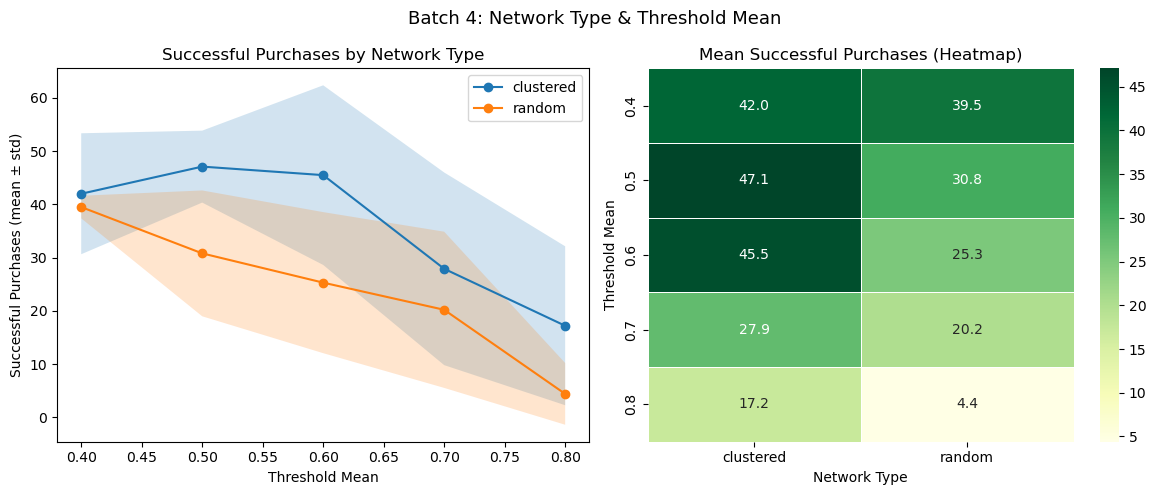

In [ ]:
# plot
fig4, axes4 = plt.subplots(1, 2, figsize=(12, 5))
fig4.suptitle("Batch 4: Network Type & Threshold Mean", fontsize=13)
 
# line plot — one line per network type
for net_type, group in df4.groupby("network_type"):
    s = group.groupby("threshold_mean")["Successful"].agg(["mean", "std"]).reset_index()
    axes4[0].plot(s["threshold_mean"], s["mean"], marker="o", label=net_type)
    axes4[0].fill_between(s["threshold_mean"],
                          s["mean"] - s["std"],
                          s["mean"] + s["std"], alpha=0.2)
 
axes4[0].set_xlabel("Threshold Mean")
axes4[0].set_ylabel("Successful Purchases (mean ± std)")
axes4[0].set_title("Successful Purchases by Network Type")
axes4[0].legend()
 
# heatmap — threshold × network type
pivot4 = df4.groupby(["threshold_mean", "network_type"])["Successful"].mean().unstack()
sns.heatmap(pivot4, ax=axes4[1], annot=True, fmt=".1f", cmap="YlGn", linewidths=0.5)
axes4[1].set_title("Mean Successful Purchases (Heatmap)")
axes4[1].set_xlabel("Network Type")
axes4[1].set_ylabel("Threshold Mean")
 
fig4.tight_layout()
plt.show()